<a href="https://colab.research.google.com/github/FrancescoRito/WEC_analysis_notebook/blob/main/WEC_Analysis_race.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Function to manage boxplot creation and display
def boxplot_to_chart(df_to_boxplot):

    #Get the unique team - car identifiers ('TEAM_NUMBER') from the input DataFrame.
    single_label = df_to_boxplot["TEAM_NUMBER"].unique()

    #Calculate the median lap time for each unique team - car to determine sorting order.
    mean_times = [] #This remains a list to store median values.
    for car in single_label:
        mean_time = df_to_boxplot['TIME_IN_SECONDS'][df_to_boxplot['TEAM_NUMBER'] == car].median() #Calculate median and store in a separate variable
        mean_times.append(mean_time) #Append the calculated median to the list

    #Determine the sorting order based on the calculated median times (fastest first).
    sorted_indices = np.argsort(mean_times)

    #Reorder the team/car labels according to the sorted indices.
    sorted_labels = single_label[sorted_indices]

    #Create a list of lap time data Series, ordered according to the sorted team - car labels.
    #This structure is often required by plotting functions like plt.boxplot().
    sorted_data = [df_to_boxplot['TIME_IN_SECONDS'][df_to_boxplot['TEAM_NUMBER'] == car] for car in sorted_labels]

    return sorted_labels, sorted_data

In [2]:
#Converts time strings in MM:SS.sss or HH:MM:SS.sss format to a timedelta object
def convert_to_timedelta(time_str):
    parts = time_str.split(':')
    if len(parts) == 2:
        minutes, seconds = parts
        seconds = seconds.ljust(3, '0')
        return f"00:{minutes}:{seconds}"
    elif len(parts) == 3:
        hours, minutes, seconds = parts
        seconds = seconds.ljust(3, '0')
        return f"{hours}:{minutes}:{seconds}"
    else:
        return time_str  #Returns the original string if the format is expected

In [3]:
# Function to determine the race hour range
def determine_hour_interval(td):
    total_seconds = int(td.total_seconds())
    hours = total_seconds // 3600
    if hours < 6:
        return f"{hours + 1}° hour"
    else:
        return "6° hour"

In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#Read the Excel file, specifying the dtype for the 'NUMBER' column as string
#!!INSERT THE CSV PATH HERE!!
df_race = pd.read_csv(filepath_or_buffer='/content/23_Analysis_Race_Hour 6.csv',sep=';', dtype={'NUMBER': str})

#Remove potential leading spaces
df_race.columns = df_race.columns.str.strip()

#Apply the custom parsing function 'convert_to_timedelta' to handle various raw time string formats
df_race['ELAPSED'] = df_race['ELAPSED'].apply(convert_to_timedelta)
#Convert the processed 'ELAPSED' column to pandas Timedelta objects.
df_race['ELAPSED'] = pd.to_timedelta(df_race['ELAPSED'])

#Create the 'HOUR_INTERVAL' column by categorizing the 'ELAPSED' time using the 'determine_hour_interval' function.
df_race['HOUR_INTERVAL'] = df_race['ELAPSED'].apply(lambda x: determine_hour_interval(pd.to_timedelta(x)))

#Subset the DataFrame to include only the needed columns
df_race = df_race[["NUMBER","LAP_NUMBER","LAP_TIME","HOUR_INTERVAL","FLAG_AT_FL","PIT_TIME","TEAM","MANUFACTURER","CLASS","DRIVER_NAME","S1_SECONDS","S2_SECONDS","S3_SECONDS"]]


#Rename the 'NUMBER' column to 'CAR_NUMBER' for better clarity
df_race = df_race.rename(columns={'NUMBER': 'CAR_NUMBER'})

#Create 'TIME_IN_SECONDS' column: sum of S1, S2, S3 sector times (rounded to 3 decimals).
df_race["TIME_IN_SECONDS"] = round(df_race["S1_SECONDS"] + df_race["S2_SECONDS"] + df_race["S3_SECONDS"],3)

#Create a combined 'TEAM_NUMBER' string (e.g., "TeamName - CarNumber") for data visualization labels.
df_race["TEAM_NUMBER"] = df_race["TEAM"]+' - '+df_race["CAR_NUMBER"]

#Create a detailed 'TEAM_NUMBER_DRIVER' string (e.g., "TeamName - CarNumber | DriverName") for data visualization labels.
df_race["TEAM_NUMBER_DRIVER"] = df_race["TEAM_NUMBER"]+' | '+ df_race["DRIVER_NAME"]

#Remove rows with missing sector times (NaN in S1/S2/S3) to prevent issues from potentially incomplete/corrupt source file.
df_race = df_race.dropna(subset=['S1_SECONDS', 'S2_SECONDS', 'S3_SECONDS'])

df_race

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,CAR_NUMBER,LAP_NUMBER,LAP_TIME,HOUR_INTERVAL,FLAG_AT_FL,PIT_TIME,TEAM,MANUFACTURER,CLASS,DRIVER_NAME,S1_SECONDS,S2_SECONDS,S3_SECONDS,TIME_IN_SECONDS,TEAM_NUMBER,TEAM_NUMBER_DRIVER
0,007,1,1:42.619,1° hour,GF,NaN,Aston Martin Thor Team,Aston Martin,HYPERCAR,Harry TINCKNELL,22.372,34.127,46.120,102.619,Aston Martin Thor Team - 007,Aston Martin Thor Team - 007 | Harry TINCKNELL
1,007,2,1:36.092,1° hour,GF,NaN,Aston Martin Thor Team,Aston Martin,HYPERCAR,Harry TINCKNELL,19.964,31.564,44.564,96.092,Aston Martin Thor Team - 007,Aston Martin Thor Team - 007 | Harry TINCKNELL
2,007,3,1:35.020,1° hour,GF,NaN,Aston Martin Thor Team,Aston Martin,HYPERCAR,Harry TINCKNELL,19.584,31.338,44.098,95.020,Aston Martin Thor Team - 007,Aston Martin Thor Team - 007 | Harry TINCKNELL
3,007,4,1:35.187,1° hour,GF,NaN,Aston Martin Thor Team,Aston Martin,HYPERCAR,Harry TINCKNELL,19.520,31.411,44.256,95.187,Aston Martin Thor Team - 007,Aston Martin Thor Team - 007 | Harry TINCKNELL
4,007,5,1:35.311,1° hour,GF,NaN,Aston Martin Thor Team,Aston Martin,HYPERCAR,Harry TINCKNELL,19.604,31.354,44.353,95.311,Aston Martin Thor Team - 007,Aston Martin Thor Team - 007 | Harry TINCKNELL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7039,99,208,1:33.717,6° hour,GF,NaN,Proton Competition,Porsche,HYPERCAR,Nicolas VARRONE,19.089,30.979,43.649,93.717,Proton Competition - 99,Proton Competition - 99 | Nicolas VARRONE
7040,99,209,1:33.739,6° hour,GF,NaN,Proton Competition,Porsche,HYPERCAR,Nicolas VARRONE,19.131,30.965,43.643,93.739,Proton Competition - 99,Proton Competition - 99 | Nicolas VARRONE
7041,99,210,1:33.636,6° hour,GF,NaN,Proton Competition,Porsche,HYPERCAR,Nicolas VARRONE,19.007,30.963,43.666,93.636,Proton Competition - 99,Proton Competition - 99 | Nicolas VARRONE
7042,99,211,1:34.517,6° hour,GF,NaN,Proton Competition,Porsche,HYPERCAR,Nicolas VARRONE,19.311,31.235,43.971,94.517,Proton Competition - 99,Proton Competition - 99 | Nicolas VARRONE


In [5]:
#Filter for HYPERCAR class entries into a new DataFrame.
df_hypercar_race = df_race[(df_race['CLASS'] == 'HYPERCAR')]


#Filter for LMGT3 class entries into a new DataFrame.
df_lmgt3_race = df_race[(df_race['CLASS'] == 'LMGT3')]

In [6]:
#Function to manage boxplot creation and display
def heatmap_to_chart_race(df_to_heatmap):
    #Calculate the median lap time, grouped by team and hour interval
    median_team_interval = df_to_heatmap.groupby(['TEAM_NUMBER', 'HOUR_INTERVAL'])['TIME_IN_SECONDS'].median().unstack()

    #Sort teams from fastest (lowest median time) to slowest
    median_team = df_to_heatmap.groupby('TEAM_NUMBER')['TIME_IN_SECONDS'].median()
    ordine_team = median_team.sort_values().index

    #Recreate the pivot table, sorting the rows based on the previously defined order (fastest car)
    pivot_values = median_team_interval.loc[ordine_team]

    return pivot_values


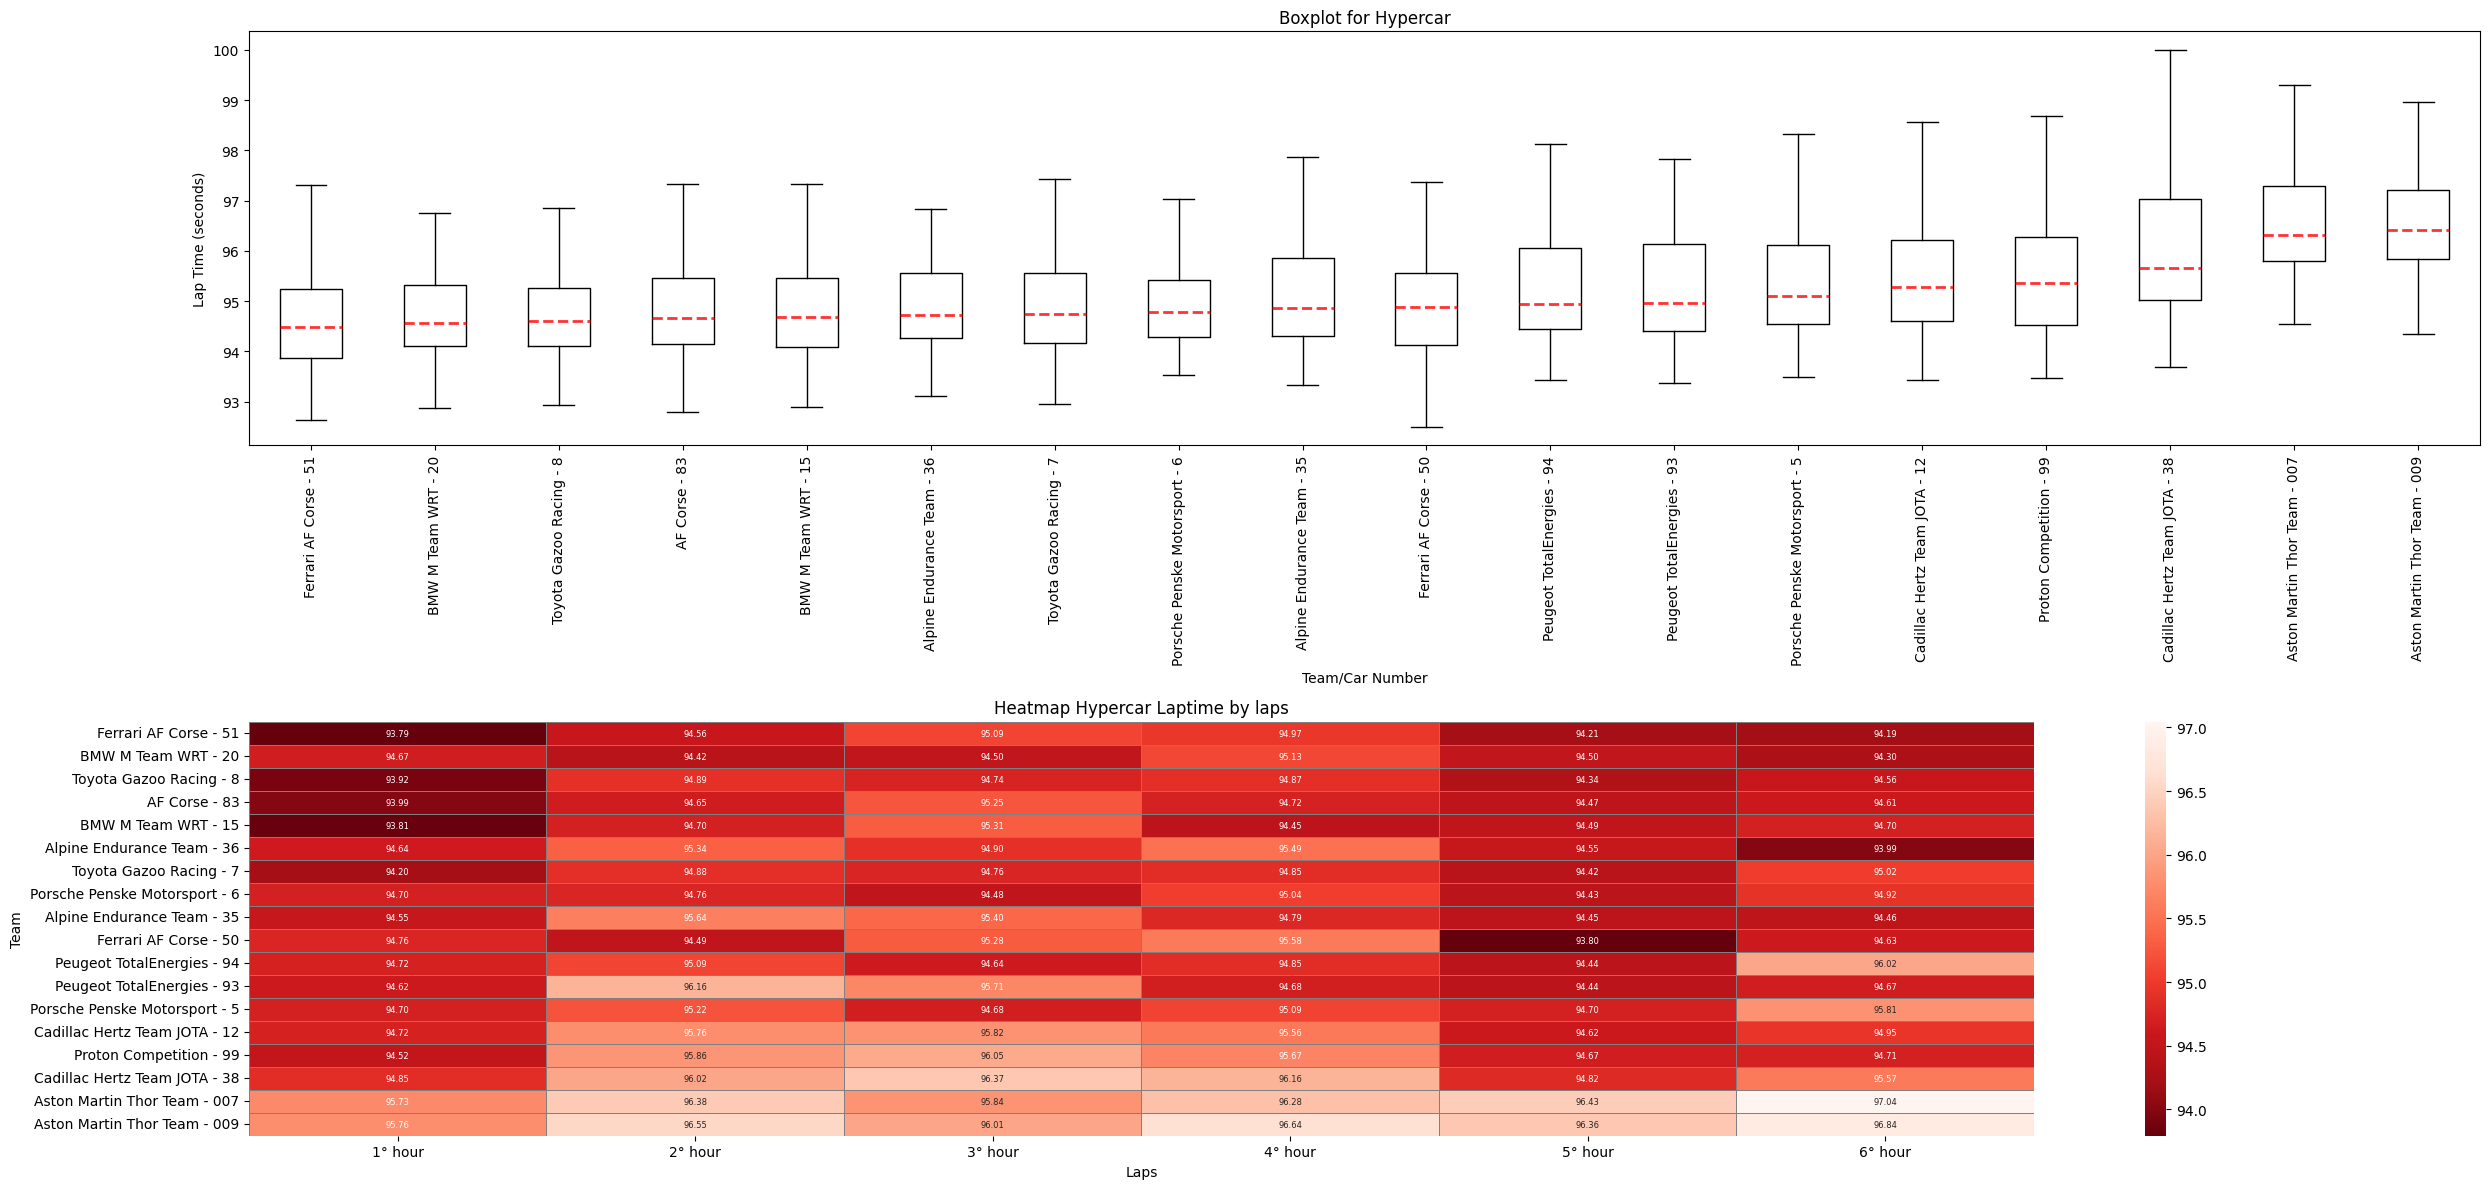

In [7]:
#HYPERCAR
#Create two vertically stacked subplots
fig, axs = plt.subplots(2, 1, figsize=(25, 12))  #2 rows, 1 column

#Prepare sorted labels and data required for the HYPERCAR class boxplot using the custom function.
sorted_labels_boxplot_hc, sorted_data_boxplot_hc = boxplot_to_chart(df_hypercar_race)

#Prepare the sorted data structure required for the HYPERCAR class race heatmap using the custom function.
sorted_data_heat_hc_race = heatmap_to_chart_race(df_hypercar_race)

#First subplot [Boxplot]
axs[0].boxplot(sorted_data_boxplot_hc, showfliers=False, tick_labels=sorted_labels_boxplot_hc,medianprops=dict(color='red', linewidth=2, linestyle='--', alpha=0.8))
axs[0].set_xlabel('Team/Car Number')
axs[0].set_ylabel('Lap Time (seconds)')
axs[0].set_title('Boxplot for Hypercar')
axs[0].tick_params(axis='x', rotation=90)

#Second subplot [Heatmap]
sns.heatmap(
    sorted_data_heat_hc_race,
    cmap='Reds_r',
    annot=True,  #Display the value in each cell
    fmt=".2f",   #Format annotations as float with two decimal places
    annot_kws={"size": 6},
    cbar=True,
    linewidths=0.5,
    linecolor='gray',
    ax=axs[1]  #Specify the axes object (the second subplot) to draw this plot on
)
axs[1].set_title('Heatmap Hypercar Laptime by laps')
axs[1].set_xlabel('Laps')
axs[1].set_ylabel('Team')

#Adjust layout to prevent overlapping elements.
plt.tight_layout()

#Display the plots
plt.show()

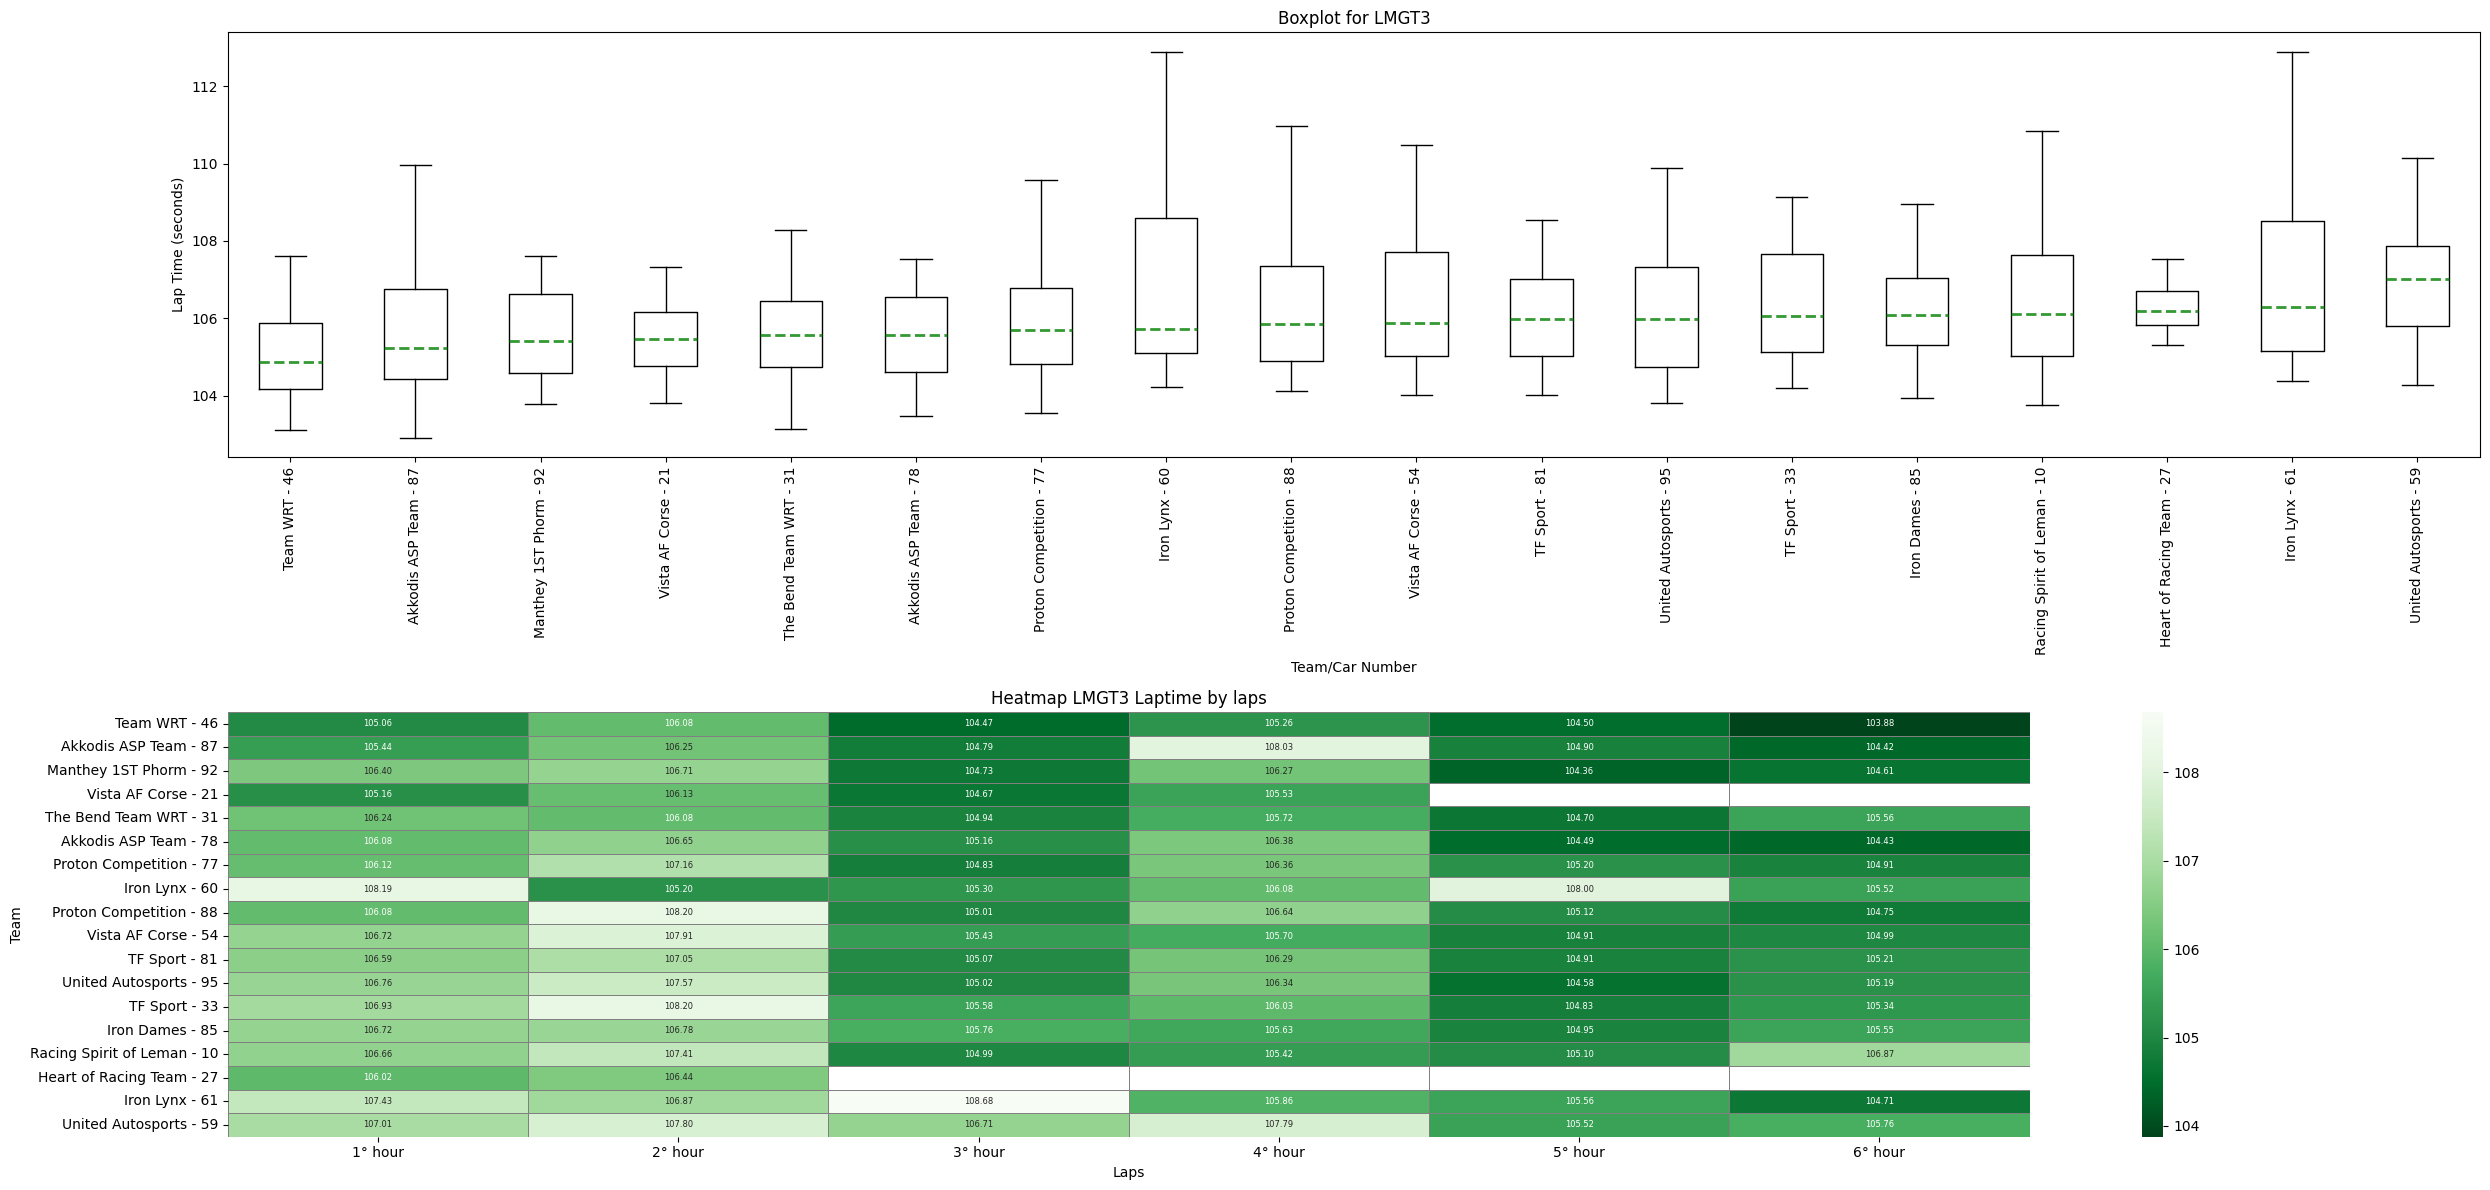

In [8]:
#LMGT3
#Create two vertically stacked subplots
fig, axs = plt.subplots(2, 1, figsize=(25, 12))  #2 rows, 1 column

#Prepare sorted labels and data required for the LMGT3 class boxplot using the custom function.
sorted_labels_boxplot_hc, sorted_data_boxplot_hc = boxplot_to_chart(df_lmgt3_race)

#Prepare the sorted data structure required for the LMGT3 class race heatmap using the custom function.
sorted_data_heat_hc_race = heatmap_to_chart_race(df_lmgt3_race)

#First subplot [Boxplot]
axs[0].boxplot(sorted_data_boxplot_hc, showfliers=False, tick_labels=sorted_labels_boxplot_hc,medianprops=dict(color='green', linewidth=2, linestyle='--', alpha=0.8))
axs[0].set_xlabel('Team/Car Number')
axs[0].set_ylabel('Lap Time (seconds)')
axs[0].set_title('Boxplot for LMGT3')
axs[0].tick_params(axis='x', rotation=90)

#Second subplot [Heatmap]
sns.heatmap(
    sorted_data_heat_hc_race,
    cmap='Greens_r',
    annot=True,  #Display the value in each cell
    fmt=".2f",   #Format annotations as float with two decimal places
    annot_kws={"size": 6},
    cbar=True,
    linewidths=0.5,
    linecolor='gray',
    ax=axs[1]  #Specify the axes object (the second subplot) to draw this plot on
)
axs[1].set_title('Heatmap LMGT3 Laptime by laps')
axs[1].set_xlabel('Laps')
axs[1].set_ylabel('Team')

#Adjust layout to prevent overlapping elements.
plt.tight_layout()

#Display the plots
plt.show()

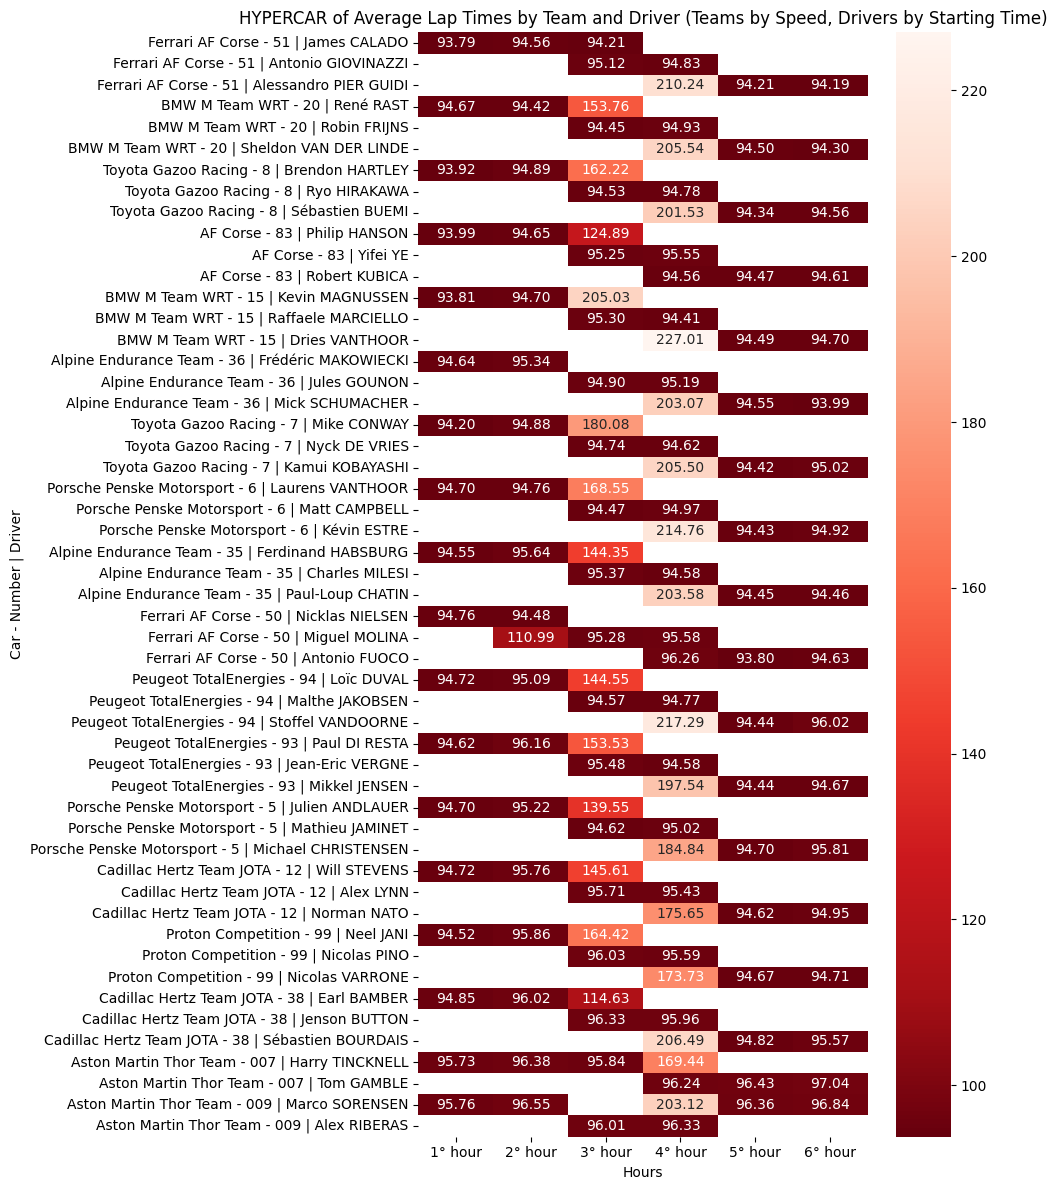

In [9]:
#Calculate median lap time per team and sort teams by speed (fastest first).
median_times = df_hypercar_race.groupby('TEAM_NUMBER')['TIME_IN_SECONDS'].median().sort_values()

#Get the sorted list of team names based on median lap time.
sorted_teams = median_times.index

#Find the first hour interval driven by each driver within each team. This helps determine the driver order within a team based on who drove earlier.
first_stint = df_hypercar_race.groupby(['TEAM_NUMBER', 'DRIVER_NAME', 'TEAM_NUMBER_DRIVER'])['HOUR_INTERVAL'].min().reset_index()

#Sort primarily by team (for grouping) and then by the first hour interval.
first_stint = first_stint.sort_values(['TEAM_NUMBER', 'HOUR_INTERVAL'])

#Create a final ordered list of 'Team - Car | Driver' labels for the heatmap index.
ordered_team_drivers = []
for team in sorted_teams:
    team_drivers = first_stint[first_stint['TEAM_NUMBER'] == team]['TEAM_NUMBER_DRIVER'].tolist()
    ordered_team_drivers.extend(team_drivers)

#Set the figure size for the heatmap.
plt.figure(figsize=(10, 12))

#Create the pivot table: Median lap time per driver per hour interval.
heatmap_data = df_hypercar_race.pivot_table(index='TEAM_NUMBER_DRIVER', columns='HOUR_INTERVAL', values='TIME_IN_SECONDS', aggfunc='median')

#Reindex the pivot table rows according to the desired sorted order (teams by speed, drivers by first stint).
heatmap_data = heatmap_data.reindex(ordered_team_drivers)

#Generate the heatmap using seaborn with specified colormap and annotations.
ax = sns.heatmap(heatmap_data, cmap='Reds_r', annot=True, fmt=".2f")

#Set axis labels
ax.set(xlabel="Hours", ylabel="Car - Number | Driver")

#Set the plot title (explaining the sorting).
plt.title('HYPERCAR of Average Lap Times by Team and Driver (Teams by Speed, Drivers by Starting Time)')

#Adjust layout to prevent overlapping elements.
plt.tight_layout()

plt.show()

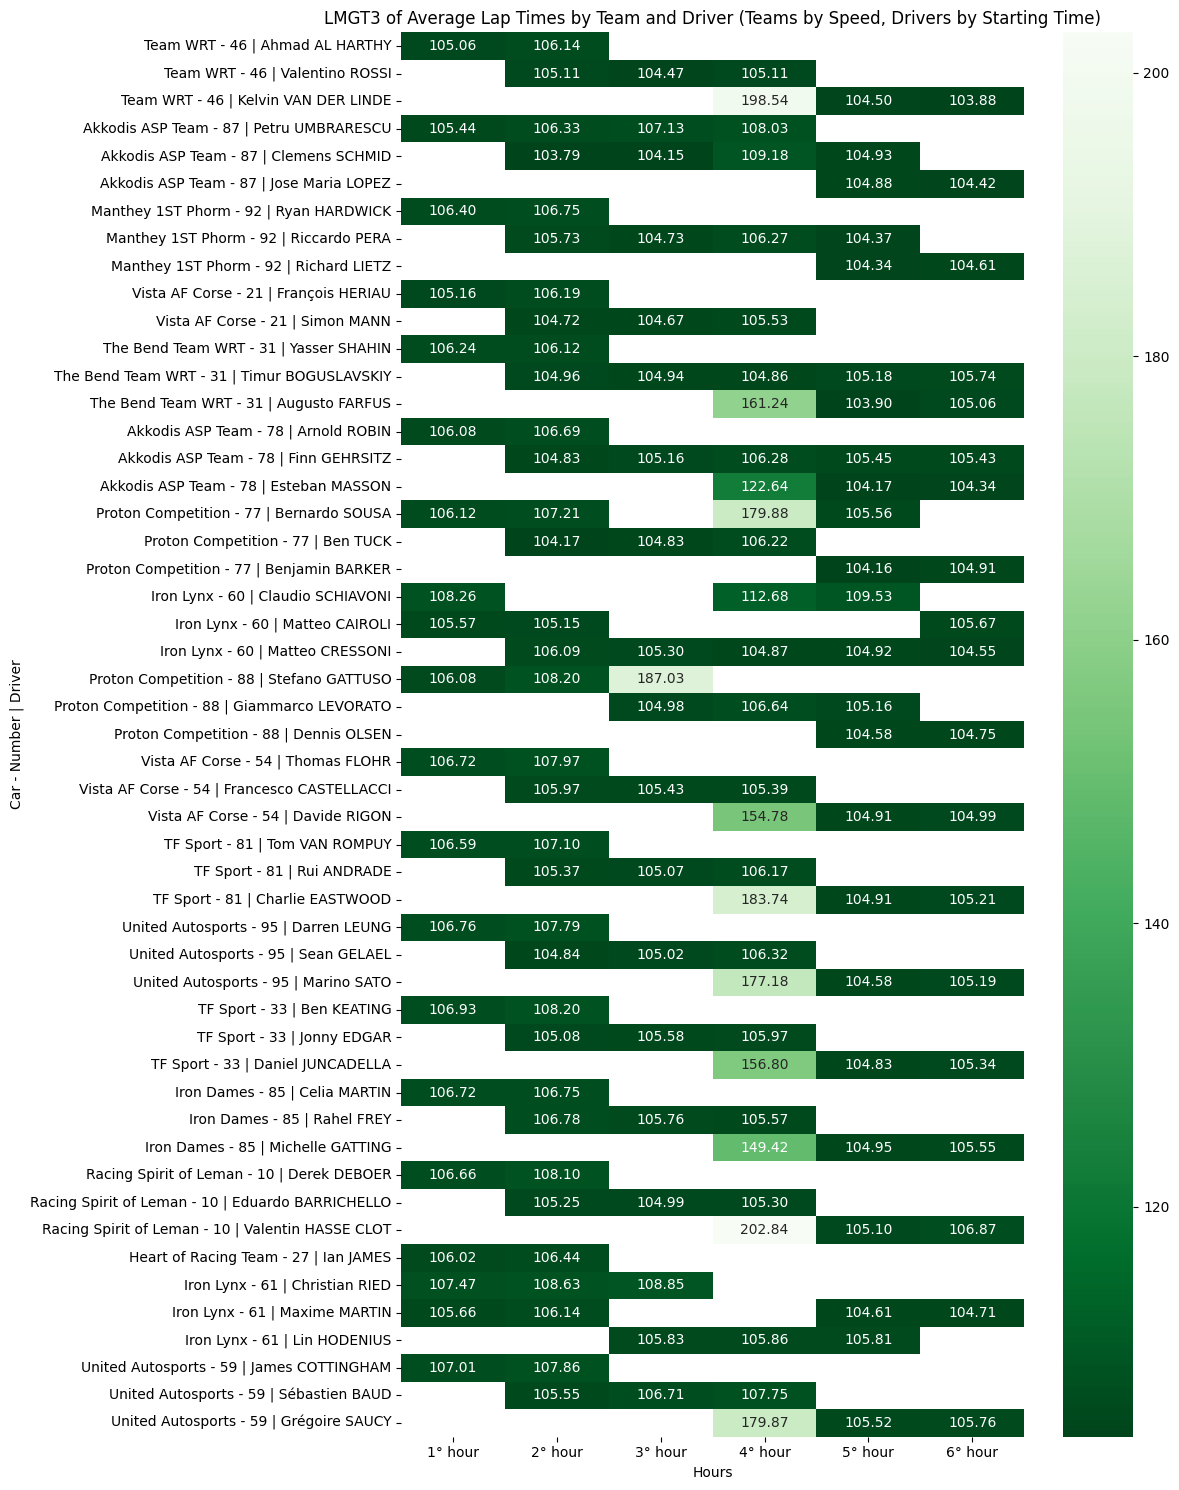

In [10]:
#Calculate median lap time per team and sort teams by speed (fastest first).
median_times = df_lmgt3_race.groupby('TEAM_NUMBER')['TIME_IN_SECONDS'].median().sort_values()

#Get the sorted list of team names based on median lap time.
sorted_teams = median_times.index

#Find the first hour interval driven by each driver within each team. This helps determine the driver order within a team based on who drove earlier.
first_stint = df_lmgt3_race.groupby(['TEAM_NUMBER', 'DRIVER_NAME', 'TEAM_NUMBER_DRIVER'])['HOUR_INTERVAL'].min().reset_index()

#Sort primarily by team (for grouping) and then by the first hour interval.
first_stint = first_stint.sort_values(['TEAM_NUMBER', 'HOUR_INTERVAL'])

#Create a final ordered list of 'Team - Car | Driver' labels for the heatmap index.
ordered_team_drivers = []
for team in sorted_teams:
    team_drivers = first_stint[first_stint['TEAM_NUMBER'] == team]['TEAM_NUMBER_DRIVER'].tolist()
    ordered_team_drivers.extend(team_drivers)

#Set the figure size for the heatmap.
plt.figure(figsize=(12, 15))

#Create the pivot table: Median lap time per driver per hour interval.
heatmap_data = df_lmgt3_race.pivot_table(index='TEAM_NUMBER_DRIVER', columns='HOUR_INTERVAL', values='TIME_IN_SECONDS', aggfunc='median')

#Reindex the pivot table rows according to the desired sorted order (teams by speed, drivers by first stint).
heatmap_data = heatmap_data.reindex(ordered_team_drivers)

#Generate the heatmap using seaborn with specified colormap and annotations.
ax = sns.heatmap(heatmap_data, cmap='Greens_r', annot=True, fmt=".2f")

#Set axis labels
ax.set(xlabel="Hours", ylabel="Car - Number | Driver")

#Set the plot title (explaining the sorting).
plt.title('LMGT3 of Average Lap Times by Team and Driver (Teams by Speed, Drivers by Starting Time)')

#Adjust layout to prevent overlapping elements.
plt.tight_layout()
plt.show()

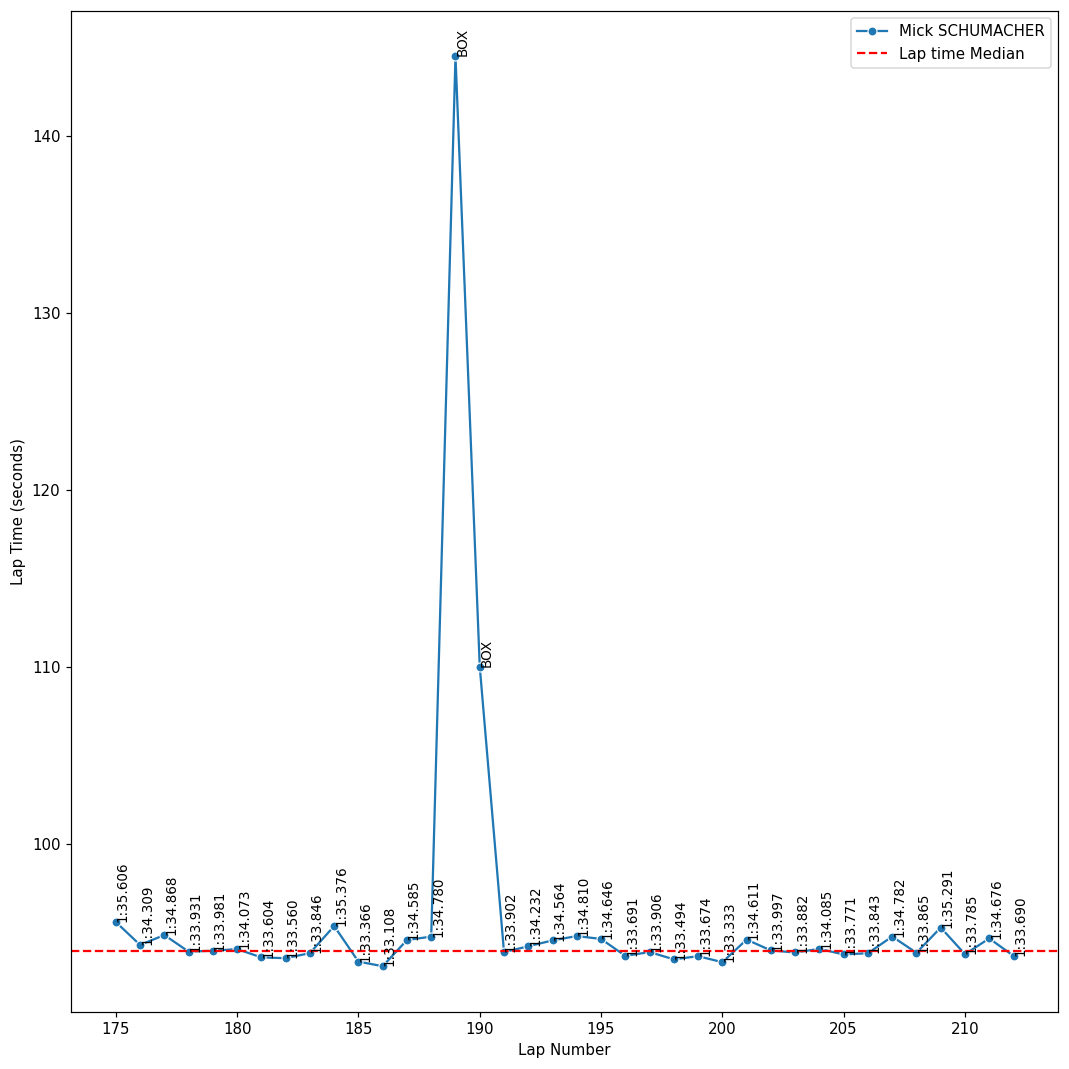

In [11]:
# CONFIGURATION: Select DRIVER and HOUR
# Define the specific driver to analyze.
driver_to_see = 'Mick SCHUMACHER'
# Define the specific hour interval to analyze.
# Note: Ensure this string exactly matches values in 'HOUR_INTERVAL'
hour_to_see = '6° hour'


#Filter the Hypercar data for the selected driver and hour interval.
#Using .copy() to avoid potential SettingWithCopyWarning on the new DataFrame 'data'.
data_exploration = df_hypercar_race[(df_hypercar_race['DRIVER_NAME'] == driver_to_see) & (df_hypercar_race['HOUR_INTERVAL'] == hour_to_see)].copy()

#Initialize 'PIT_CHART' column to mark pit-related laps for visualization. (0 = Normal lap, 1 = Pit stop lap or lap immediately preceding pit stop).
data_exploration['PIT_CHART'] = 0

#Mark laps associated with pit stops (current lap and the preceding lap).
#Iterate through the laps for the selected driver/hour stint.
for index, row in data_exploration.iterrows():
    #Check if PIT_TIME has a value for this lap (indicating a pit stop occurred).
    if pd.notnull(row["PIT_TIME"]):
        #Mark this lap as pit-related.
        data_exploration.loc[index, "PIT_CHART"] = 1
        #Also mark the previous lap (potential in-lap) as pit-related,
        #checking we're not on the first lap (index > 0).
        if index > 0:
            data_exploration.loc[index - 1, "PIT_CHART"] = 1

#Calculate the median lap time for this specific driver/hour stint.
median_time = data_exploration['TIME_IN_SECONDS'].median()



#Set the figure size for the plot.
plt.figure(figsize=(10, 10), dpi=108)

#Lineplot with markers. x-axis: Lap Number, y-axis: Lap Time in Seconds.
sns.lineplot(x="LAP_NUMBER", y="TIME_IN_SECONDS", hue="DRIVER_NAME", data=data_exploration, marker='o')

#Add a horizontal line representing the median lap time for this stint.
plt.axhline(y=median_time, color='red', linestyle='--', label=f'Lap time Median')


#Annotate each point on the plot with lap time or "BOX" for pit laps.
#Iterate through the laps again.
for index, row in data_exploration.iterrows():
    #Use "BOX" as label for pit-related laps, otherwise use the formatted lap time string ('LAP_TIME').
    lap_time_label = "BOX" if row['PIT_CHART'] == 1 else row['LAP_TIME']
    #Add the text label to the plot near the data point, rotated for readability.
    plt.text(row['LAP_NUMBER'], row['TIME_IN_SECONDS'], lap_time_label, fontsize=9, ha='left', va='bottom', rotation=90)

#Set axis labels.
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)') # Clarified unit

# Display the plot legend (shows median line and driver name from hue).
plt.legend()

# Ensure layout is tight to prevent overlap.
plt.tight_layout()


plt.show()